# 06 — Nested CV CSP Tuning

## Objective

Test whether controlled CSP hyperparameter selection improves
subject-independent motor-imagery decoding compared to the
Week 6 baseline.

Hyperparameters will be selected using group-aware inner
cross-validation containing only the outer training subjects.

The held-out outer subject will not participate in CSP fitting,
LDA fitting, or hyperparameter selection.

We want to figure out if the nested-cross validation-based CSP-tuning improves accuracy compared to the baseline

The preprocessing protocol, classification task, and outer
leave-one-subject-out evaluation are kept unchanged from Week 6.

### Imports

In [1]:
from pathlib import Path
import sys

import mne
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import (
    LeaveOneGroupOut,
    GroupKFold,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score

mne.set_log_level("WARNING")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from neurosignallab.preprocessing import preprocess_subject

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "eegbci"

### Load all patients

In [2]:
subjects = range(1, 110)

X_parts = []
y_parts = []
group_parts = []

for subject in subjects:

    X_subject, y_subject, metadata_subject = preprocess_subject(
        subject=subject,
        data_dir=DATA_DIR
    )

    X_parts.append(X_subject)
    y_parts.append(y_subject)
    group_parts.append(
        metadata_subject["subject"].to_numpy()
    )

X = np.concatenate(X_parts, axis=0)
y = np.concatenate(y_parts)
groups = np.concatenate(group_parts)

del X_parts, y_parts, group_parts

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)
print("Number of subjects:", len(np.unique(groups)))

/Users/heihei/Desktop/neurosignallab/src/neurosignallab/preprocessing.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_run = mne.io.read_raw_edf(
/Users/heihei/Desktop/neurosignallab/src/neurosignallab/preprocessing.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_run = mne.io.read_raw_edf(
/Users/heihei/Desktop/neurosignallab/src/neurosignallab/preprocessing.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_run = mne.io.read_raw_edf(


X shape: (4898, 64, 481)
y shape: (4898,)
groups shape: (4898,)
Number of subjects: 109


### Create model and regulations

In [3]:
model = Pipeline([
    ("csp", CSP(log=True)),
    ("lda", LinearDiscriminantAnalysis())
])

param_grid = {
    "csp__n_components": [2, 4, 6, 8],
    "csp__reg": [None, "ledoit_wolf"] #Ledoit_wolf is an MNE covariance estimator that estimates shrinkage
}

### Define cross-validation layers

In [4]:
outer_cv = LeaveOneGroupOut()

inner_cv = GroupKFold(
    n_splits=5
)

### Inspect one fold

In [5]:
outer_train_idx, outer_test_idx = next(
    outer_cv.split(X, y, groups)
)

print(
    "Outer test subject:",
    np.unique(groups[outer_test_idx])
)

print(
    "Outer training subjects:",
    len(np.unique(groups[outer_train_idx]))
)

print(
    "Outer training trials:",
    len(outer_train_idx)
)

print(
    "Outer test trials:",
    len(outer_test_idx)
)

Outer test subject: [1]
Outer training subjects: 108
Outer training trials: 4853
Outer test trials: 45


### Create model evaluation

In [6]:
search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=inner_cv,
    refit=True
)

### search for best model and fit the model

In [7]:
search.fit(
    X[outer_train_idx],
    y[outer_train_idx],
    groups=groups[outer_train_idx]
)

# This creates the grid for the gridsearc
# Basically we vary from 2-8 components
# And we run through once without regularization 
# And another time with
# We have 5 folds
# So we get 8*5 grid for the gridsearch
# The 2-8 and regularization or not gets repeated for every fold

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...tAnalysis())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'csp__n_components': [2, 4, ...], 'csp__reg': [None, 'ledoit_wolf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",GroupKFold(n_...shuffle=False)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbos

### Inspect selected parameter for inner loop

In [8]:
print("Best parameters:", search.best_params_)
print("Best inner balanced accuracy:", search.best_score_)

Best parameters: {'csp__n_components': 4, 'csp__reg': None}
Best inner balanced accuracy: 0.5815876242098582


### Check accuracy for Subject 1

In [9]:
y_pred = search.predict(
    X[outer_test_idx]
)

outer_score = balanced_accuracy_score(
    y[outer_test_idx],
    y_pred
)

print("Outer test balanced accuracy:", outer_score)

Outer test balanced accuracy: 0.6304347826086957


## Full Nested Cross-Validation

Repeat the nested model-selection procedure for every outer
leave-one-subject-out fold.

For each outer fold:

1. One subject is completely held out.
2. Five-fold GroupKFold is used within the remaining subjects.
3. The eight predefined CSP configurations are compared using balanced accuracy (2-8 with or without regularization).
4. The best configuration is refitted on all outer-training subjects.
5. The refitted model is evaluated on the untouched outer test subject.

The selected hyperparameters, inner validation score, and outer test
score are recorded for every subject.

In [10]:
checkpoint_path = (
    PROJECT_ROOT
    / "results"
    / "week7_nested_cv_checkpoint.csv"
)

if checkpoint_path.exists():
    tuned_results_df = pd.read_csv(checkpoint_path)
    tuned_results = tuned_results_df.to_dict("records")
    completed_subjects = set(
        tuned_results_df["subject"].astype(int)
    )
else:
    tuned_results = []
    completed_subjects = set()


for outer_train_idx, outer_test_idx in outer_cv.split(X, y, groups):

    held_out_subject = int(groups[outer_test_idx[0]])

    if held_out_subject in completed_subjects:
        continue

    search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=inner_cv,
        refit=True
    )

    search.fit(
        X[outer_train_idx],
        y[outer_train_idx],
        groups=groups[outer_train_idx]
    )

    y_pred = search.predict(
        X[outer_test_idx]
    )

    tuned_results.append({
        "subject": held_out_subject,
        "balanced_accuracy": balanced_accuracy_score(
            y[outer_test_idx],
            y_pred
        ),
        "best_inner_ba": search.best_score_,
        "best_n_components": search.best_params_[
            "csp__n_components"
        ],
        "best_reg": search.best_params_[
            "csp__reg"
        ]
    })

    pd.DataFrame(tuned_results).to_csv(
        checkpoint_path,
        index=False
    )

    completed_subjects.add(held_out_subject)

    print("Finished and saved subject:", held_out_subject)


tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df

Finished and saved subject: 86
Finished and saved subject: 87
Finished and saved subject: 88
Finished and saved subject: 89
Finished and saved subject: 90
Finished and saved subject: 91
Finished and saved subject: 92
Finished and saved subject: 93
Finished and saved subject: 94
Finished and saved subject: 95
Finished and saved subject: 96
Finished and saved subject: 97
Finished and saved subject: 98
Finished and saved subject: 99
Finished and saved subject: 100
Finished and saved subject: 101
Finished and saved subject: 102
Finished and saved subject: 103
Finished and saved subject: 104
Finished and saved subject: 105
Finished and saved subject: 106
Finished and saved subject: 107
Finished and saved subject: 108
Finished and saved subject: 109


,subject,balanced_accuracy,best_inner_ba,best_n_components,best_reg
0,1,0.630435,0.581588,4,NaN
1,2,0.776680,0.579070,4,NaN
2,3,0.485178,0.582560,4,NaN
3,4,0.606719,0.582502,4,NaN
4,5,0.500000,0.583281,6,NaN
...,...,...,...,...,...
104,105,0.500988,0.577789,4,NaN
105,106,0.583333,0.568231,6,NaN
106,107,0.619048,0.570933,8,NaN
107,108,0.803360,0.572632,6,NaN


### Save to csv

In [11]:
checkpoint_path = (
    PROJECT_ROOT
    / "results"
    / "week7_nested_cv_checkpoint.csv"
)

pd.DataFrame(tuned_results).to_csv(
    checkpoint_path,
    index=False
)

### Summarize outer performance

In [12]:
print(
    "Mean tuned balanced accuracy:",
    tuned_results_df["balanced_accuracy"].mean()
)

print(
    "Median tuned balanced accuracy:",
    tuned_results_df["balanced_accuracy"].median()
)

print(
    "Minimum tuned balanced accuracy:",
    tuned_results_df["balanced_accuracy"].min()
)

print(
    "Maximum tuned balanced accuracy:",
    tuned_results_df["balanced_accuracy"].max()
)

Mean tuned balanced accuracy: 0.5753086109354076
Median tuned balanced accuracy: 0.5327380952380952
Minimum tuned balanced accuracy: 0.3830049261083744
Maximum tuned balanced accuracy: 0.9110671936758892


### Check statistic for components and regulators

In [13]:
tuned_results_df["best_reg"] = (
    tuned_results_df["best_reg"]
    .fillna("None")
)

print(
    tuned_results_df["best_n_components"]
    .value_counts()
    .sort_index()
)

print(
    tuned_results_df["best_reg"]
    .value_counts()
)

best_n_components
4    16
6    41
8    52
Name: count, dtype: int64
best_reg
None    109
Name: count, dtype: int64


### Load week 6 results

In [14]:
fixed_results = pd.read_csv(
    PROJECT_ROOT
    / "results"
    / "csp_lda_cross_subject_summary.csv"
)

### Compare week 6 and week 7 results

In [15]:
week7_comparison = fixed_results[
    ["subject", "balanced_accuracy"]
].rename(
    columns={"balanced_accuracy": "fixed_ba"}
)

week7_comparison = week7_comparison.merge(
    tuned_results_df[
        ["subject", "balanced_accuracy"]
    ].rename(
        columns={"balanced_accuracy": "tuned_ba"}
    ),
    on="subject"
)

week7_comparison["difference"] = (
    week7_comparison["tuned_ba"]
    - week7_comparison["fixed_ba"]
)

week7_comparison

,subject,fixed_ba,tuned_ba,difference
0,1,0.630435,0.630435,0.000000
1,2,0.776680,0.776680,0.000000
2,3,0.485178,0.485178,0.000000
3,4,0.606719,0.606719,0.000000
4,5,0.500000,0.500000,0.000000
...,...,...,...,...
104,105,0.500988,0.500988,0.000000
105,106,0.541667,0.583333,0.041667
106,107,0.568452,0.619048,0.050595
107,108,0.782609,0.803360,0.020751


### Summarize comparison

In [16]:
print(
    "Mean change:",
    week7_comparison["difference"].mean()
)

print(
    "Median change:",
    week7_comparison["difference"].median()
)

print(
    "Improved:",
    np.sum(week7_comparison["difference"] > 0)
)

print(
    "Worsened:",
    np.sum(week7_comparison["difference"] < 0)
)

print(
    "Unchanged:",
    np.sum(week7_comparison["difference"] == 0)
)

Mean change: 0.009861114063485357
Median change: 0.0
Improved: 41
Worsened: 37
Unchanged: 31


### Paired comparison scatter-plot

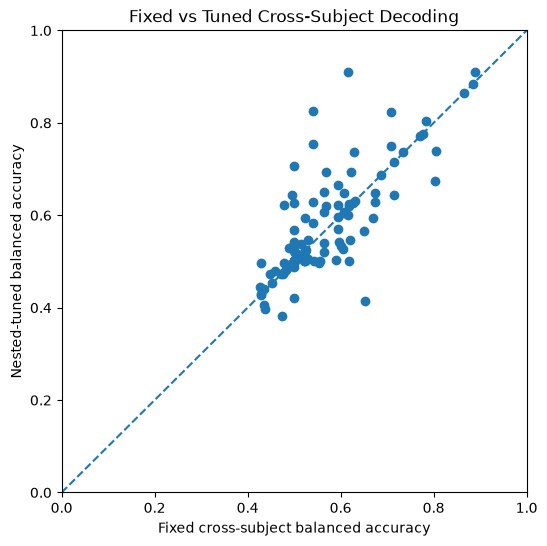

In [17]:


plt.figure(figsize=(6, 6))

plt.scatter(
    week7_comparison["fixed_ba"],
    week7_comparison["tuned_ba"]
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Fixed cross-subject balanced accuracy")
plt.ylabel("Nested-tuned balanced accuracy")
plt.title("Fixed vs Tuned Cross-Subject Decoding")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.show()

## Summary

This experiment tested whether controlled CSP hyperparameter selection
could improve subject-independent motor-imagery decoding compared with
the Week 6 baseline.

Hyperparameter selection was performed using nested cross-validation.

The outer evaluation used Leave-One-Subject-Out cross-validation across
all 109 subjects. For each outer fold, the held-out subject was
completely excluded from model fitting and hyperparameter selection.

Within the remaining 108 subjects, five-fold GroupKFold was used to
compare eight predefined CSP configurations:

- n_components = 2, 4, 6, or 8
- covariance regularization = None or Ledoit-Wolf

Balanced accuracy was used for both inner model selection and outer
evaluation.

### Performance

The fixed Week 6 cross-subject baseline achieved a mean balanced
accuracy of approximately 0.565.

The nested-tuned procedure achieved:

- mean balanced accuracy: 0.575
- median balanced accuracy: 0.533
- minimum balanced accuracy: 0.383
- maximum balanced accuracy: 0.911

Compared with the fixed baseline:

- mean change: +0.0099 balanced-accuracy points
- median change: 0.000
- 41 subjects improved
- 37 subjects worsened
- 31 subjects were unchanged

Nested hyperparameter selection therefore produced an average
improvement of approximately one percentage point, but the benefit was
not uniform across subjects.

### Hyperparameter selection

The selected number of CSP components varied across outer folds:

- 4 components: 16 subjects
- 6 components: 41 subjects
- 8 components: 52 subjects
- 2 components: 0 subjects

Six or eight components were therefore selected in 93 of the 109 outer
folds.

Ledoit-Wolf covariance regularization was selected in none of the 109
outer folds. Every inner search preferred empirical covariance
estimation without CSP regularization.

This indicates that, within the Week 7 search space,
increasing the number of retained CSP components was more useful than
introducing Ledoit-Wolf covariance shrinkage.

### Interpretation

Nested tuning improved mean subject-independent decoding only
modestly.

Although inner cross-validation frequently preferred six or eight CSP
components over the original four-component baseline, this preference
translated into an improvement of approximately
0.01 balanced-accuracy points.

The median change was zero, and substantial numbers of subjects
improved, worsened, or remained unchanged.

This demonstrates why hyperparameter-configuration can appear
preferable during inner validation without producing a large or
consistent improvement on completely unseen subjects.

The experiment also provides no evidence that Ledoit-Wolf covariance
regularization is useful for this particular CSP + LDA setup. 

The predefined Week 7 search is now considered complete. Additional
hyperparameters will not be added in response to the observed outer
results.

### Save final csv

In [18]:
tuned_results_df["best_reg"] = (
    tuned_results_df["best_reg"]
    .fillna("None")
)

tuned_path = (
    PROJECT_ROOT
    / "results"
    / "csp_lda_nested_tuned_cross_subject_summary.csv"
)

comparison_path = (
    PROJECT_ROOT
    / "results"
    / "fixed_vs_tuned_cross_subject_comparison.csv"
)

if not tuned_path.exists():
    tuned_results_df.to_csv(
        tuned_path,
        index=False
    )

if not comparison_path.exists():
    week7_comparison.to_csv(
        comparison_path,
        index=False
    )